#  Fraud Detection Pipeline Analysis

This notebook analyzes telemetry data from our end-to-end fraud detection system powered by **Abide AgentKit**.

## System Overview
- **Data Collection Agent**: Fetches user profiles and enriches transaction context
- **Risk Analysis Agent**: Analyzes fraud risk using ML models and makes decisions  
- **Alert Management Agent**: Handles notifications and dashboard updates

## Abide AgentKit Features Analyzed
This notebook demonstrates comprehensive analysis of **Abide AgentKit's specialized agent logging**:
-  **Agent Thinking** (`logger.thinking()`) - Agent reasoning and thought processes
-  **Agent Actions** (`logger.action()`) - Operations performed by agents
-  **Agent Decisions** (`logger.decision()`) - Decisions with reasoning and options
-  **Agent Observations** (`logger.observation()`) - Data and events observed with confidence

## Analysis Goals
- Agent behavior patterns using Abide AgentKit logging features
- Agent performance metrics and latency analysis
- Decision reasoning quality and patterns
- Risk assessment patterns and accuracy
- Pipeline throughput and bottlenecks
- Error analysis and system reliability
- OpenTelemetry-style comprehensive observability


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import glob
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style for fraud detection theme
plt.style.use('default')
sns.set_palette(["#2E8B57", "#FF6347", "#4169E1", "#FFD700", "#8A2BE2"])
plt.rcParams['figure.figsize'] = (14, 8)

print(" Fraud Detection Analysis Libraries Loaded!")
print(" Ready to analyze agent telemetry data")

 Fraud Detection Analysis Libraries Loaded!
 Ready to analyze agent telemetry data


##  Load Fraud Detection Telemetry Data

Load all fraud detection log files and parse them into structured DataFrames for comprehensive analysis.


In [3]:
def load_fraud_detection_logs(pattern="fraud_detection_logs*.jsonl"):
    """Load all fraud detection log files."""
    
    log_files = glob.glob(pattern)
    print(f" Found {len(log_files)} fraud detection log files:")
    for file in log_files:
        print(f"   {file}")
    
    all_logs = []
    
    for file_path in log_files:
        print(f"\n Loading {file_path}...")
        
        with open(file_path, 'r') as f:
            file_logs = []
            for line_num, line in enumerate(f, 1):
                if line.strip():
                    try:
                        log_entry = json.loads(line.strip())
                        log_entry['source_file'] = file_path
                        log_entry['line_number'] = line_num
                        file_logs.append(log_entry)
                    except json.JSONDecodeError as e:
                        print(f" Error parsing line {line_num}: {e}")
            \
            print(f"   Loaded {len(file_logs)} events")
            all_logs.extend(file_logs)
    
    print(f"\n Total fraud detection events loaded: {len(all_logs)}")
    return all_logs

# Load the fraud detection logs
raw_logs = load_fraud_detection_logs()

 Found 16 fraud detection log files:
   fraud_detection_logs_20251111_012110.jsonl
   fraud_detection_logs_20251116_185815.jsonl
   fraud_detection_logs_20251106_202553.jsonl
   fraud_detection_logs_20251106_201701.jsonl
   fraud_detection_logs_20251106_181349.jsonl
   fraud_detection_logs_20251111_012342.jsonl
   fraud_detection_logs_20251106_194447.jsonl
   fraud_detection_logs_20251106_201650.jsonl
   fraud_detection_logs_20251106_215638.jsonl
   fraud_detection_logs_20251117_184342.jsonl
   fraud_detection_logs_20251111_014221.jsonl
   fraud_detection_logs_20251106_202356.jsonl
   fraud_detection_logs_20251106_202136.jsonl
   fraud_detection_logs_20251106_201947.jsonl
   fraud_detection_logs_20251106_215830.jsonl
   fraud_detection_logs_20251111_011856.jsonl

 Loading fraud_detection_logs_20251111_012110.jsonl...
   Loaded 103 events

 Loading fraud_detection_logs_20251116_185815.jsonl...
   Loaded 1260 events

 Loading fraud_detection_logs_20251106_202553.jsonl...
   Loaded 153 ev

In [4]:
def parse_fraud_logs_to_dataframe(logs):
    """Convert fraud detection logs to structured DataFrames."""
    
    parsed_data = []
    
    for log in logs:
        # Base fields
        row = {
            'trace_id': log.get('trace_id'),
            'event_id': log.get('event_id'),
            'event_type': log.get('event_type'),
            'conversation_id': log.get('conversation_id'),
            'run_id': log.get('run_id'),
            'span_id': log.get('span_id'),
            'level': log.get('level'),
            'success': log.get('success'),
            'error': log.get('error'),
            'sampled': log.get('sampled'),
            'source_file': log.get('source_file')
        }
        
        # Agent information
        agent = log.get('agent', {})
        row.update({
            'agent_name': agent.get('name'),
            'agent_role': agent.get('role'),
            'agent_version': agent.get('version')
        })
        
        # Action information
        action = log.get('action', {})
        if action:
            row.update({
                'action_type': action.get('type'),
                'action_name': action.get('name'),
                'action_input': str(action.get('input', ''))[:500],
                'action_output': str(action.get('output', ''))[:500],
                'action_success': action.get('success')
            })
        
        # Model call information
        model_call = log.get('model_call', {})
        if model_call:
            row.update({
                'model_backend': model_call.get('backend'),
                'model_name': model_call.get('model'),
                'input_tokens': model_call.get('input_token_count'),
                'output_tokens': model_call.get('output_token_count'),
                'total_tokens': model_call.get('total_token_count')
            })
        
        # Telemetry/timing information
        telemetry = log.get('telemetry', {})
        if telemetry:
            row.update({
                'timestamp_start': telemetry.get('timestamp_start'),
                'timestamp_end': telemetry.get('timestamp_end'),
                'latency_ms': telemetry.get('latency_ms'),
                'timestamp_iso': telemetry.get('timestamp_start_iso'),
                'throughput_tokens_per_sec': telemetry.get('throughput_tokens_per_sec')
            })
        
        # Metadata (fraud-specific fields)
        metadata = log.get('metadata', {})
        row.update({
            'message': metadata.get('message'),
            'transaction_id': metadata.get('transaction_id'),
            'user_id': metadata.get('user_id'),
            'amount': metadata.get('amount'),
            'merchant': metadata.get('merchant'),
            'location': metadata.get('location'),
            'risk_score': metadata.get('risk_score'),
            'risk_level': metadata.get('risk_level'),
            'decision': metadata.get('decision'),
            'confidence': metadata.get('confidence'),
            'factors': str(metadata.get('factors', [])),
            'metric_name': metadata.get('metric_name'),
            'metric_value': metadata.get('value'),
            'metric_unit': metadata.get('unit'),
            'error_type': metadata.get('error_type'),
            'environment': metadata.get('environment'),
            'pipeline_step': metadata.get('pipeline_step'),
            'operation': metadata.get('operation'),
            'channel': metadata.get('channel'),
            'processing_duration_ms': metadata.get('processing_duration_ms'),
            'analysis_version': metadata.get('analysis_version'),
            # Agent-specific logging fields from abidex
            'agent_thought': metadata.get('thought'),
            'agent_action': metadata.get('action'),
            'agent_decision': metadata.get('decision'),
            'agent_reasoning': metadata.get('reasoning'),
            'agent_options': str(metadata.get('options', {})),
            'agent_observation': metadata.get('observation'),
            'observation_source': metadata.get('source'),
            'observation_confidence': metadata.get('confidence'),
            'agent_context': str(metadata.get('context', {})),
            'action_details': str(metadata.get('details', {}))
        })
        
        # Tags (fraud-specific + agent logging tags)
        tags = log.get('tags', {})
        row.update({
            'tag_agent': tags.get('agent'),
            'tag_operation': tags.get('operation'),
            'tag_decision': tags.get('decision'),
            'tag_channel': tags.get('channel'),
            'tag_pipeline': tags.get('pipeline'),
            'tag_step': tags.get('step'),
            'tag_system': tags.get('system'),
            # Agent logging event types from abidex
            'agent_event_type': tags.get('event_type'),  # thinking, action, decision, observation
            'logger_name': tags.get('logger'),
            'source': tags.get('source')
        })
        
        # Add raw metadata as JSON string for complex queries
        row['metadata_json'] = json.dumps(metadata) if metadata else None
        row['tags_json'] = json.dumps(tags) if tags else None
        
        parsed_data.append(row)
    
    df = pd.DataFrame(parsed_data)
    
    # Convert timestamps
    if 'timestamp_iso' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp_iso'], errors='coerce')
    
    # Convert numeric fields
    numeric_fields = ['amount', 'risk_score', 'confidence', 'latency_ms', 'processing_duration_ms', 
                     'input_tokens', 'output_tokens', 'total_tokens', 'metric_value', 'observation_confidence']
    for field in numeric_fields:
        if field in df.columns:
            df[field] = pd.to_numeric(df[field], errors='coerce')
    
    print(f" Fraud Detection DataFrame created with {len(df)} rows and {len(df.columns)} columns")
    return df

# Parse logs to DataFrame
df = parse_fraud_logs_to_dataframe(raw_logs)

# Display basic info
print(f"\n Fraud Detection Data Overview:")
if len(df) > 0:
    print(f"  • Time range: {df['timestamp'].min()} to {df['timestamp'].max()}")
    print(f"  • Event types: {dict(df['event_type'].value_counts())}")
    print(f"  • Agents: {dict(df['agent_name'].value_counts())}")
    print(f"  • Decisions: {dict(df[df['decision'].notna()]['decision'].value_counts())}")
else:
    print("   No data loaded - make sure to run the fraud detection pipeline first!")

 Fraud Detection DataFrame created with 7007 rows and 73 columns

 Fraud Detection Data Overview:
  • Time range: 2025-11-06 18:13:49.983723 to 2025-11-17 18:44:12.390174
  • Event types: {'log': np.int64(3745), 'metric': np.int64(2462), 'error': np.int64(450), 'agent_run_start': np.int64(150), 'agent_run_end': np.int64(150), 'model_call_start': np.int64(50)}
  • Agents: {'FraudDetectionSystem': np.int64(2907), 'Data Collection Agent': np.int64(600), 'Risk Analysis Agent': np.int64(554), 'Alert Management Agent': np.int64(540)}
  • Decisions: {'flag': np.int64(128), 'select_alert_channels': np.int64(79), 'flag_for_review': np.int64(56), 'approve': np.int64(49), 'block': np.int64(48), 'approve_transaction': np.int64(21)}


##  System Overview Dashboard

Create a comprehensive overview of the fraud detection system performance.


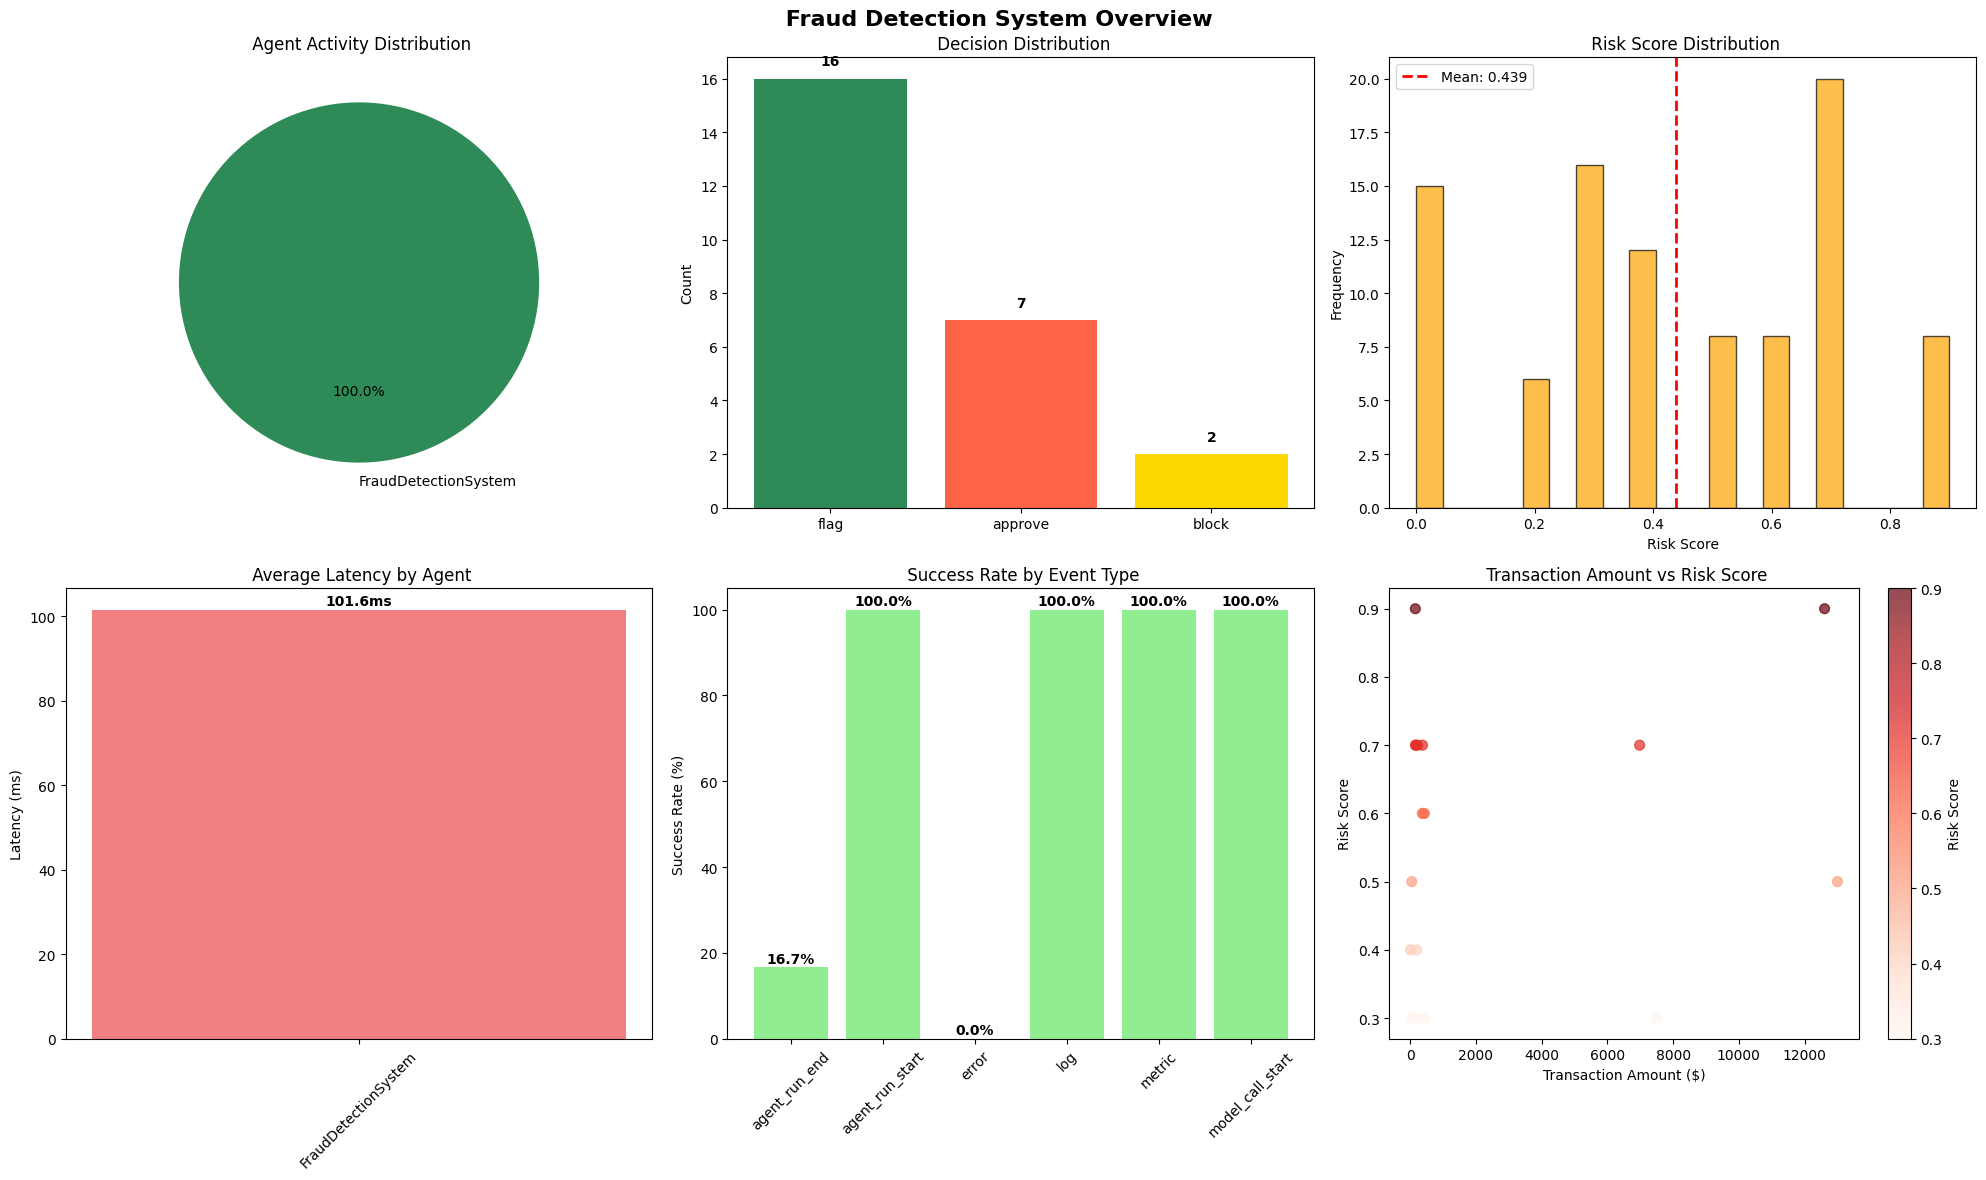


 KEY SYSTEM METRICS
 Total Events: 1,592
 Total Transactions: 363
 Average Latency: 101.6ms
 Overall Success Rate: 76.4%

 Decision Breakdown:
  • Flag: 16 (533.3%)
  • Approve: 7 (233.3%)
  • Block: 2 (66.7%)


In [4]:
# System Overview Dashboard
if len(df) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle(' Fraud Detection System Overview', fontsize=16, fontweight='bold')
    
    # 1. Agent Activity Distribution
    agent_counts = df['agent_name'].value_counts()
    axes[0,0].pie(agent_counts.values, labels=agent_counts.index, autopct='%1.1f%%', startangle=90)
    axes[0,0].set_title(' Agent Activity Distribution')
    
    # 2. Decision Distribution
    decisions = df[df['decision'].notna()]['decision'].value_counts()
    if len(decisions) > 0:
        colors = ['#2E8B57', '#FF6347', '#FFD700']  # Green, Red, Gold
        axes[0,1].bar(decisions.index, decisions.values, color=colors[:len(decisions)])
        axes[0,1].set_title(' Decision Distribution')
        axes[0,1].set_ylabel('Count')
        for i, v in enumerate(decisions.values):
            axes[0,1].text(i, v + 0.5, str(v), ha='center', fontweight='bold')
    
    # 3. Risk Score Distribution
    risk_scores = df[df['risk_score'].notna()]['risk_score']
    if len(risk_scores) > 0:
        axes[0,2].hist(risk_scores, bins=20, alpha=0.7, color='orange', edgecolor='black')
        axes[0,2].axvline(risk_scores.mean(), color='red', linestyle='--', linewidth=2, 
                         label=f'Mean: {risk_scores.mean():.3f}')
        axes[0,2].set_title(' Risk Score Distribution')
        axes[0,2].set_xlabel('Risk Score')
        axes[0,2].set_ylabel('Frequency')
        axes[0,2].legend()
    
    # 4. Processing Latency by Agent
    latency_data = df[df['latency_ms'].notna()]
    if len(latency_data) > 0:
        agent_latency = latency_data.groupby('agent_name')['latency_ms'].mean().sort_values(ascending=False)
        axes[1,0].bar(agent_latency.index, agent_latency.values, color='lightcoral')
        axes[1,0].set_title(' Average Latency by Agent')
        axes[1,0].set_ylabel('Latency (ms)')
        axes[1,0].tick_params(axis='x', rotation=45)
        for i, v in enumerate(agent_latency.values):
            axes[1,0].text(i, v + 1, f'{v:.1f}ms', ha='center', fontweight='bold')
    
    # 5. Success Rate by Event Type
    success_by_type = df.groupby('event_type')['success'].mean() * 100
    axes[1,1].bar(success_by_type.index, success_by_type.values, color='lightgreen')
    axes[1,1].set_title(' Success Rate by Event Type')
    axes[1,1].set_ylabel('Success Rate (%)')
    axes[1,1].set_ylim(0, 105)
    axes[1,1].tick_params(axis='x', rotation=45)
    for i, v in enumerate(success_by_type.values):
        axes[1,1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
    
    # 6. Transaction Amounts vs Risk Scores
    transaction_data = df[(df['amount'].notna()) & (df['risk_score'].notna())]
    if len(transaction_data) > 0:
        scatter = axes[1,2].scatter(transaction_data['amount'], transaction_data['risk_score'], 
                                  c=transaction_data['risk_score'], cmap='Reds', alpha=0.7, s=50)
        axes[1,2].set_title(' Transaction Amount vs Risk Score')
        axes[1,2].set_xlabel('Transaction Amount ($)')
        axes[1,2].set_ylabel('Risk Score')
        plt.colorbar(scatter, ax=axes[1,2], label='Risk Score')
    
    plt.tight_layout()
    plt.show()
    
    # Print key metrics
    print("\n KEY SYSTEM METRICS")
    print("=" * 40)
    total_events = len(df)
    total_transactions = len(df[df['transaction_id'].notna()])
    avg_latency = df['latency_ms'].mean() if df['latency_ms'].notna().any() else 0
    success_rate = (df['success'].mean() * 100) if df['success'].notna().any() else 0
    
    print(f" Total Events: {total_events:,}")
    print(f" Total Transactions: {total_transactions:,}")
    print(f" Average Latency: {avg_latency:.1f}ms")
    print(f" Overall Success Rate: {success_rate:.1f}%")
    
    if len(decisions) > 0:
        print(f"\n Decision Breakdown:")
        for decision, count in decisions.items():
            percentage = (count / len(decisions)) * 100
            print(f"  • {decision.title()}: {count} ({percentage:.1f}%)")
    
else:
    print(" No data available for dashboard. Run the fraud detection pipeline first!")

##  Advanced Fraud Detection Analysis

Deep dive into agent-specific performance and fraud detection patterns.


In [5]:
# Advanced Agent Performance Analysis
print(" AGENT PERFORMANCE DEEP DIVE")
print("=" * 50)

if len(df) > 0:
    # Agent-specific metrics analysis
    agents = ['Data Collection Agent', 'Risk Analysis Agent', 'Alert Management Agent']
    
    print("\n Agent Performance Metrics:")
    for agent in agents:
        agent_data = df[df['agent_name'] == agent]
        if len(agent_data) > 0:
            avg_latency = agent_data['latency_ms'].mean()
            success_rate = agent_data['success'].mean() * 100
            event_count = len(agent_data)
            
            print(f"\n {agent}:")
            print(f"  • Events: {event_count}")
            print(f"  • Avg Latency: {avg_latency:.1f}ms")
            print(f"  • Success Rate: {success_rate:.1f}%")
            
            # Agent-specific operations
            operations = agent_data['operation'].value_counts()
            if len(operations) > 0:
                print(f"  • Top Operations: {dict(operations.head(3))}")
    
    # Model Performance Analysis
    print(f"\n MODEL PERFORMANCE ANALYSIS:")
    model_data = df[df['model_name'].notna()]
    if len(model_data) > 0:
        model_perf = model_data.groupby(['model_name', 'model_backend']).agg({
            'latency_ms': ['count', 'mean', 'std'],
            'total_tokens': ['mean', 'sum'],
            'success': 'mean'
        }).round(2)
        
        model_perf.columns = ['calls', 'avg_latency', 'std_latency', 'avg_tokens', 'total_tokens', 'success_rate']
        model_perf['success_rate'] = model_perf['success_rate'] * 100
        print(model_perf)
    
    # Transaction Risk Analysis
    print(f"\n TRANSACTION RISK ANALYSIS:")
    risk_data = df[df['risk_score'].notna()]
    if len(risk_data) > 0:
        risk_stats = risk_data.groupby('decision').agg({
            'risk_score': ['count', 'mean', 'std', 'min', 'max'],
            'amount': ['mean', 'std'],
            'confidence': 'mean'
        }).round(3)
        
        print("Risk Score Statistics by Decision:")
        print(risk_stats)
        
        # Risk factors analysis
        print(f"\n Risk Factors Analysis:")
        all_factors = []
        for factors_str in risk_data['factors'].dropna():
            if factors_str and factors_str != '[]':
                try:
                    factors_list = eval(factors_str)  # Convert string representation back to list
                    all_factors.extend(factors_list)
                except:
                    pass
        
        if all_factors:
            factor_counts = Counter(all_factors)
            print("Most Common Risk Factors:")
            for factor, count in factor_counts.most_common(5):
                print(f"  • {factor}: {count} occurrences")
    
    # Alert Channel Analysis
    print(f"\n ALERT SYSTEM ANALYSIS:")
    alert_data = df[df['channel'].notna()]
    if len(alert_data) > 0:
        channel_stats = alert_data['channel'].value_counts()
        print("Alert Distribution by Channel:")
        for channel, count in channel_stats.items():
            print(f"  • {channel}: {count} alerts")
    
    # Metrics Analysis
    print(f"\n CUSTOM METRICS ANALYSIS:")
    metrics_data = df[df['metric_name'].notna()]
    if len(metrics_data) > 0:
        metric_summary = metrics_data.groupby(['metric_name', 'metric_unit']).agg({
            'metric_value': ['count', 'mean', 'std', 'min', 'max']
        }).round(3)
        print("System Metrics Summary:")
        print(metric_summary)

else:
    print(" No data available. Run the fraud detection pipeline first!")

 AGENT PERFORMANCE DEEP DIVE

 Agent Performance Metrics:

 Data Collection Agent:
  • Events: 600
  • Avg Latency: nanms
  • Success Rate: 100.0%

 Risk Analysis Agent:
  • Events: 554
  • Avg Latency: nanms
  • Success Rate: 100.0%

 Alert Management Agent:
  • Events: 540
  • Avg Latency: nanms
  • Success Rate: 100.0%

 MODEL PERFORMANCE ANALYSIS:
                                        calls  avg_latency  std_latency  \
model_name               model_backend                                    
fraud-detection-model-v2 ml_engine         25       220.27        59.59   
user-profile-model       internal_db       25       106.17        32.85   

                                        avg_tokens  total_tokens  success_rate  
model_name               model_backend                                          
fraud-detection-model-v2 ml_engine             NaN           0.0         100.0  
user-profile-model       internal_db           NaN           0.0         100.0  

 TRANSACTION RISK AN

##  Time Series Analysis & Patterns

Analyze temporal patterns in fraud detection operations.


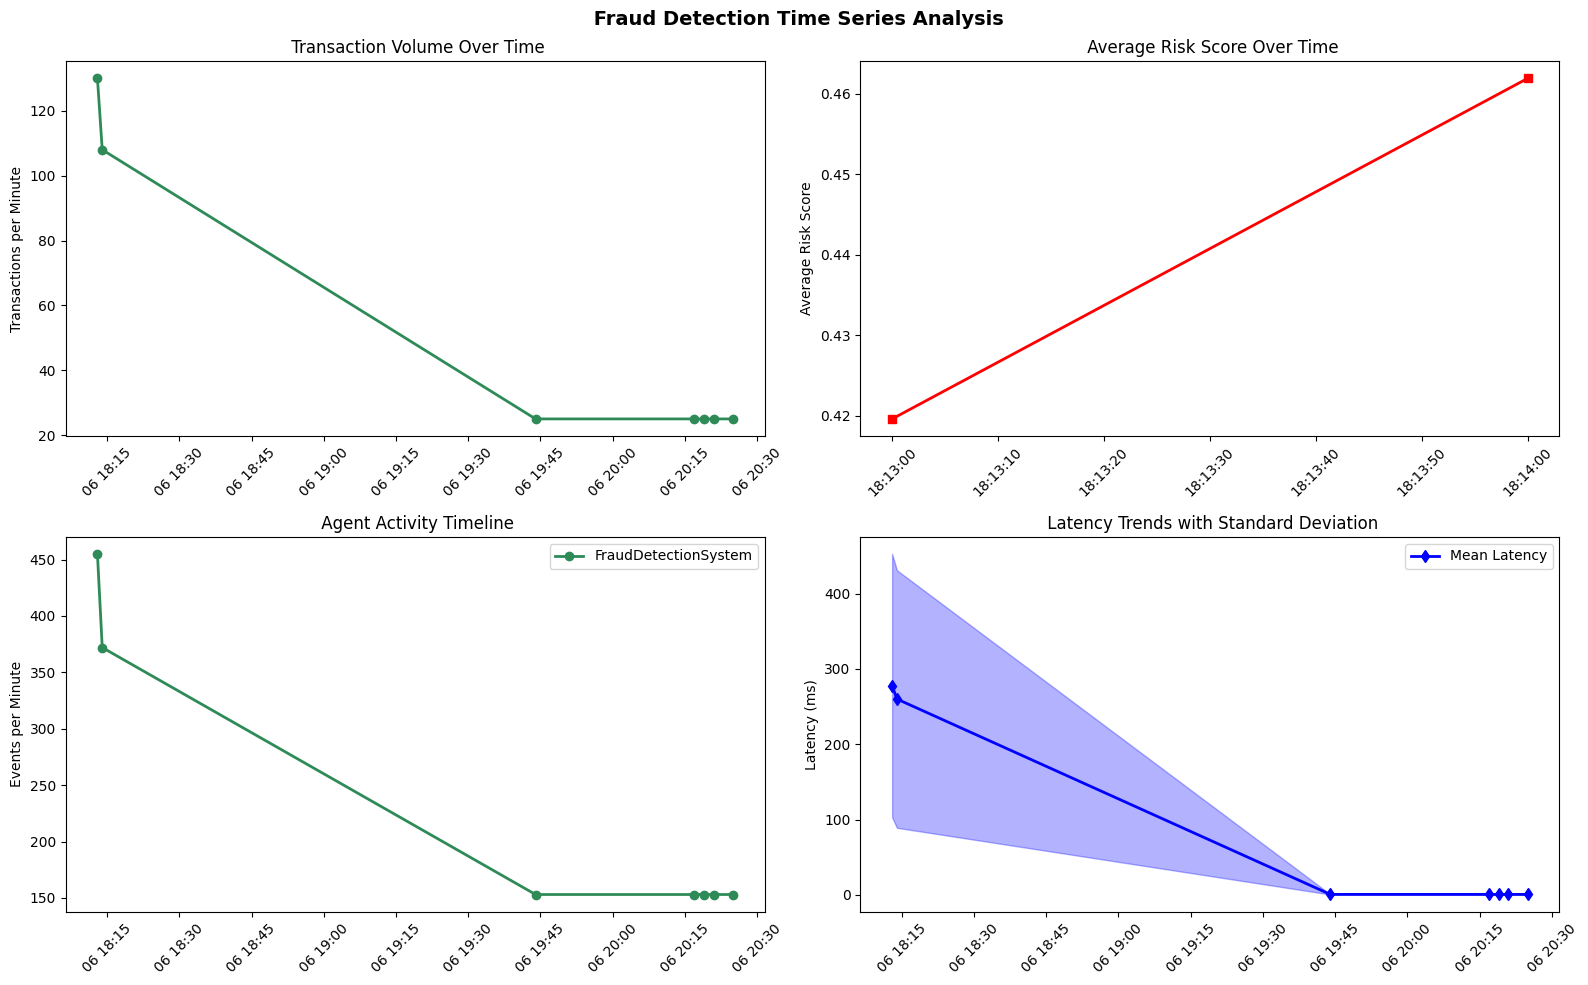


 TIME-BASED INSIGHTS:
 Peak Transaction Time: 2025-11-06 18:13:00 (130 transactions)
 Highest Risk Period: 2025-11-06 18:14:00 (Risk: 0.462)
 Average System Latency: 101.6ms
 Latency Trend: Decreasing by 46.24ms per minute (performance improving)


In [6]:
# Time Series Analysis
if len(df) > 0 and 'timestamp' in df.columns and df['timestamp'].notna().any():
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(' Fraud Detection Time Series Analysis', fontsize=14, fontweight='bold')
    
    # 1. Transaction Volume Over Time
    transaction_events = df[df['transaction_id'].notna()].copy()
    if len(transaction_events) > 0:
        transaction_events['minute'] = transaction_events['timestamp'].dt.floor('1T')  # Round to minute
        volume_by_minute = transaction_events.groupby('minute').size()
        
        axes[0,0].plot(volume_by_minute.index, volume_by_minute.values, marker='o', linewidth=2)
        axes[0,0].set_title(' Transaction Volume Over Time')
        axes[0,0].set_ylabel('Transactions per Minute')
        axes[0,0].tick_params(axis='x', rotation=45)
    
    # 2. Risk Score Trends
    risk_events = df[df['risk_score'].notna()].copy()
    if len(risk_events) > 0:
        risk_events['minute'] = risk_events['timestamp'].dt.floor('1T')
        risk_trends = risk_events.groupby('minute')['risk_score'].mean()
        
        axes[0,1].plot(risk_trends.index, risk_trends.values, color='red', marker='s', linewidth=2)
        axes[0,1].set_title(' Average Risk Score Over Time')
        axes[0,1].set_ylabel('Average Risk Score')
        axes[0,1].tick_params(axis='x', rotation=45)
    
    # 3. Agent Activity Timeline
    agent_timeline = df[df['agent_name'].notna()].copy()
    if len(agent_timeline) > 0:
        agent_timeline['minute'] = agent_timeline['timestamp'].dt.floor('1T')
        agent_activity = agent_timeline.groupby(['minute', 'agent_name']).size().unstack(fill_value=0)
        
        for agent in agent_activity.columns:
            axes[1,0].plot(agent_activity.index, agent_activity[agent], 
                          marker='o', label=agent, linewidth=2)
        
        axes[1,0].set_title(' Agent Activity Timeline')
        axes[1,0].set_ylabel('Events per Minute')
        axes[1,0].legend()
        axes[1,0].tick_params(axis='x', rotation=45)
    
    # 4. Latency Trends
    latency_events = df[df['latency_ms'].notna()].copy()
    if len(latency_events) > 0:
        latency_events['minute'] = latency_events['timestamp'].dt.floor('1T')
        latency_trends = latency_events.groupby('minute')['latency_ms'].agg(['mean', 'std'])
        
        axes[1,1].plot(latency_trends.index, latency_trends['mean'], 
                      color='blue', marker='d', linewidth=2, label='Mean Latency')
        axes[1,1].fill_between(latency_trends.index, 
                              latency_trends['mean'] - latency_trends['std'],
                              latency_trends['mean'] + latency_trends['std'],
                              alpha=0.3, color='blue')
        
        axes[1,1].set_title(' Latency Trends with Standard Deviation')
        axes[1,1].set_ylabel('Latency (ms)')
        axes[1,1].legend()
        axes[1,1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Print time-based insights
    print("\n TIME-BASED INSIGHTS:")
    print("=" * 30)
    
    if len(transaction_events) > 0:
        peak_minute = volume_by_minute.idxmax()
        peak_volume = volume_by_minute.max()
        print(f" Peak Transaction Time: {peak_minute} ({peak_volume} transactions)")
    
    if len(risk_events) > 0:
        highest_risk_time = risk_trends.idxmax()
        highest_risk = risk_trends.max()
        print(f" Highest Risk Period: {highest_risk_time} (Risk: {highest_risk:.3f})")
    
    # Processing efficiency over time
    if len(latency_events) > 0:
        avg_latency = latency_events['latency_ms'].mean()
        print(f" Average System Latency: {avg_latency:.1f}ms")
        
        # Identify performance degradation
        if len(latency_trends) > 1:
            latency_trend = latency_trends['mean'].diff().mean()
            if latency_trend > 0:
                print(f" Latency Trend: Increasing by {latency_trend:.2f}ms per minute (performance degrading)")
            else:
                print(f" Latency Trend: Decreasing by {abs(latency_trend):.2f}ms per minute (performance improving)")

else:
    print(" No timestamp data available for time series analysis")

##  OpenTelemetry-Style Comprehensive Metrics

Showcase all the comprehensive metrics we capture, similar to OpenTelemetry standards.


In [7]:
# Comprehensive Metrics Analysis
print(" COMPREHENSIVE METRICS")
print("=" * 60)

if len(df) > 0:
    print("\n COVERAGE ANALYSIS:")
    print("=" * 40)
    
    # Core telemetry fields coverage
    telemetry_fields = {
        'trace_id': 'Distributed Tracing',
        'span_id': 'Span Tracking', 
        'run_id': 'Operation Context',
        'timestamp': 'Temporal Data',
        'latency_ms': 'Performance Metrics',
        'success': 'Reliability Metrics',
        'agent_name': 'Service Identification',
        'model_name': 'Resource Tracking',
        'total_tokens': 'Resource Usage',
        'risk_score': 'Business Metrics',
        'error': 'Error Tracking'
    }
    
    for field, description in telemetry_fields.items():
        if field in df.columns:
            coverage = (df[field].notna().sum() / len(df)) * 100
            status = "" if coverage > 50 else "" if coverage > 10 else ""
            print(f"{status} {description}: {coverage:.1f}% coverage ({df[field].notna().sum()}/{len(df)})")
    
    print(f"\n PERFORMANCE METRICS (OpenTelemetry Style):")
    print("=" * 50)
    
    # Latency percentiles (P50, P95, P99)
    latencies = df['latency_ms'].dropna()
    if len(latencies) > 0:
        p50 = latencies.quantile(0.50)
        p95 = latencies.quantile(0.95)
        p99 = latencies.quantile(0.99)
        
        print(f" Latency Metrics:")
        print(f"  • P50 (Median): {p50:.1f}ms")
        print(f"  • P95: {p95:.1f}ms")
        print(f"  • P99: {p99:.1f}ms")
        print(f"  • Max: {latencies.max():.1f}ms")
    
    # Throughput metrics
    if 'timestamp' in df.columns and df['timestamp'].notna().any():
        time_span = (df['timestamp'].max() - df['timestamp'].min()).total_seconds()
        if time_span > 0:
            throughput = len(df) / time_span
            transaction_throughput = len(df[df['transaction_id'].notna()]) / time_span
            
            print(f"\\n Throughput Metrics:")
            print(f"  • Events per second: {throughput:.2f}")
            print(f"  • Transactions per second: {transaction_throughput:.2f}")
    
    # Error rate analysis
    total_events = len(df)
    error_events = len(df[df['success'] == False])
    error_rate = (error_events / total_events) * 100 if total_events > 0 else 0
    
    print(f"\\n Error Rate Analysis:")
    print(f"  • Total Events: {total_events:,}")
    print(f"  • Failed Events: {error_events:,}")
    print(f"  • Error Rate: {error_rate:.2f}%")
    print(f"  • Success Rate: {100-error_rate:.2f}%")
    
    # Resource utilization
    print(f"\\n RESOURCE UTILIZATION:")
    print("=" * 30)
    
    # Token usage analysis
    token_data = df[df['total_tokens'].notna()]
    if len(token_data) > 0:
        total_tokens = token_data['total_tokens'].sum()
        avg_tokens_per_call = token_data['total_tokens'].mean()
        
        print(f" Token Usage:")
        print(f"  • Total Tokens Consumed: {total_tokens:,}")
        print(f"  • Average per Model Call: {avg_tokens_per_call:.1f}")
        print(f"  • Model Calls: {len(token_data)}")
    
    # Agent resource usage
    print(f"\\n Agent Resource Distribution:")
    agent_resource = df.groupby('agent_name').agg({
        'latency_ms': ['count', 'sum', 'mean'],
        'total_tokens': 'sum'
    }).fillna(0)
    
    if len(agent_resource) > 0:
        for agent in agent_resource.index:
            if pd.notna(agent):
                calls = agent_resource.loc[agent, ('latency_ms', 'count')]
                total_time = agent_resource.loc[agent, ('latency_ms', 'sum')]
                avg_time = agent_resource.loc[agent, ('latency_ms', 'mean')]
                tokens = agent_resource.loc[agent, ('total_tokens', 'sum')]
                
                print(f"   {agent}:")
                print(f"    • Calls: {calls}")
                print(f"    • Total Processing Time: {total_time:.1f}ms")
                print(f"    • Avg Processing Time: {avg_time:.1f}ms")
                if tokens > 0:
                    print(f"    • Tokens Used: {tokens:,}")
    
    print(f"\\n BUSINESS METRICS:")
    print("=" * 25)
    
    # Fraud detection specific metrics
    decisions = df[df['decision'].notna()]['decision'].value_counts()
    if len(decisions) > 0:
        print(f" Decision Distribution:")
        total_decisions = decisions.sum()
        for decision, count in decisions.items():
            percentage = (count / total_decisions) * 100
            print(f"  • {decision.title()}: {count} ({percentage:.1f}%)")
        
        # Risk assessment metrics
        risk_data = df[df['risk_score'].notna()]
        if len(risk_data) > 0:
            avg_risk = risk_data['risk_score'].mean()
            high_risk_count = len(risk_data[risk_data['risk_score'] > 0.7])
            high_risk_rate = (high_risk_count / len(risk_data)) * 100
            
            print(f"\\n Risk Assessment:")
            print(f"  • Average Risk Score: {avg_risk:.3f}")
            print(f"  • High Risk Transactions (>0.7): {high_risk_count} ({high_risk_rate:.1f}%)")
    
    # Alert effectiveness
    alert_data = df[df['channel'].notna()]
    if len(alert_data) > 0:
        alert_channels = alert_data['channel'].value_counts()
        print(f"\\n Alert Distribution:")
        for channel, count in alert_channels.items():
            print(f"  • {channel}: {count} alerts")
    
    print(f"\\n TRACE ANALYSIS:")
    print("=" * 20)
    
    # Distributed tracing analysis
    unique_traces = df['trace_id'].nunique()
    unique_runs = df['run_id'].nunique()
    events_per_trace = len(df) / unique_traces if unique_traces > 0 else 0
    
    print(f" Tracing Coverage:")
    print(f"  • Unique Traces: {unique_traces}")
    print(f"  • Unique Runs: {unique_runs}")
    print(f"  • Average Events per Trace: {events_per_trace:.1f}")
    
    # Span analysis
    spans_with_parent = df['span_id'].notna().sum()
    span_coverage = (spans_with_parent / len(df)) * 100
    print(f"  • Span Coverage: {span_coverage:.1f}%")

else:
    print(" No data available for comprehensive metrics analysis")

 COMPREHENSIVE METRICS

 COVERAGE ANALYSIS:
 Distributed Tracing: 100.0% coverage (1592/1592)
 Span Tracking: 26.7% coverage (425/1592)
 Operation Context: 60.5% coverage (963/1592)
 Temporal Data: 100.0% coverage (1592/1592)
 Performance Metrics: 12.6% coverage (200/1592)
 Reliability Metrics: 100.0% coverage (1592/1592)
 Service Identification: 100.0% coverage (1592/1592)
 Resource Tracking: 3.1% coverage (50/1592)
 Resource Usage: 0.0% coverage (0/1592)
 Business Metrics: 5.8% coverage (93/1592)
 Error Tracking: 23.6% coverage (375/1592)

 PERFORMANCE METRICS (OpenTelemetry Style):
 Latency Metrics:
  • P50 (Median): 0.5ms
  • P95: 520.4ms
  • P99: 609.1ms
  • Max: 652.0ms
\n Throughput Metrics:
  • Events per second: 0.20
  • Transactions per second: 0.05
\n Error Rate Analysis:
  • Total Events: 1,592
  • Failed Events: 375
  • Error Rate: 23.56%
  • Success Rate: 76.44%
\n RESOURCE UTILIZATION:
\n Agent Resource Distribution:
   FraudDetectionSystem:
    • Calls: 200
    • Total 

##  Agent Behavior Analysis (Abide AgentKit Features)

Analyze the specialized agent logging features from Abide AgentKit:
- **Agent Thinking**: Reasoning and thought processes
- **Agent Actions**: Operations performed by agents
- **Agent Decisions**: Decisions made with reasoning
- **Agent Observations**: Data and events observed


 AGENT BEHAVIOR ANALYSIS (Abide AgentKit)

 Agent Event Types (from get_agent_logger):
agent_event_type
action         138
thinking        92
observation     69
decision        63
Name: count, dtype: int64


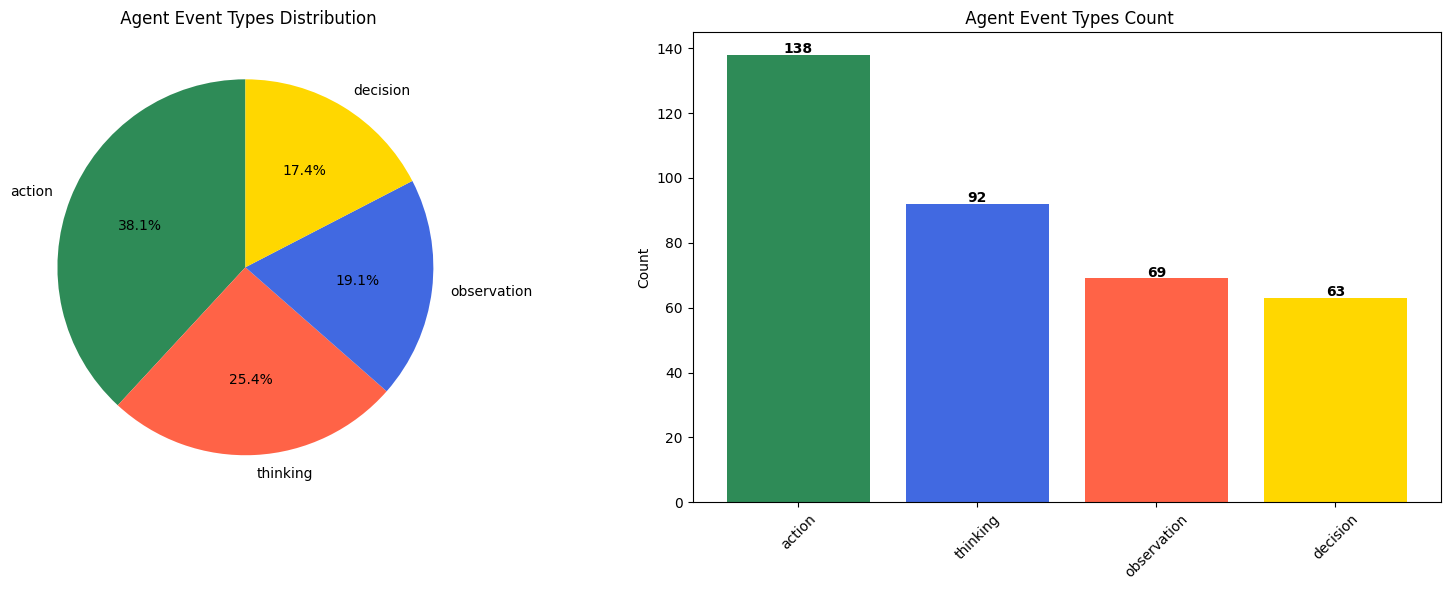


 AGENT THINKING ANALYSIS:
Total thinking events: 92

Thinking events by agent:
agent_name
Alert Management Agent    17
Data Collection Agent     50
Risk Analysis Agent       25
dtype: int64

 Sample Agent Thoughts:
  • Data Collection Agent: I need to fetch comprehensive user profile data for user user_3602
  • Data Collection Agent: Enriching transaction txn_20251111_0001 with additional context data
  • Risk Analysis Agent: Analyzing fraud risk for transaction txn_20251111_0001. Amount: $9115.932395501983, User risk histor...
  • Alert Management Agent: Determining alert channels for critical risk transaction txn_20251111_0001
  • Data Collection Agent: I need to fetch comprehensive user profile data for user user_4550

 AGENT ACTIONS ANALYSIS:
Total action events: 138

Actions by agent:
agent_action            analyze_fraud_risk  approve_transaction  \
agent_name                                                        
Alert Management Agent                   0                    0 

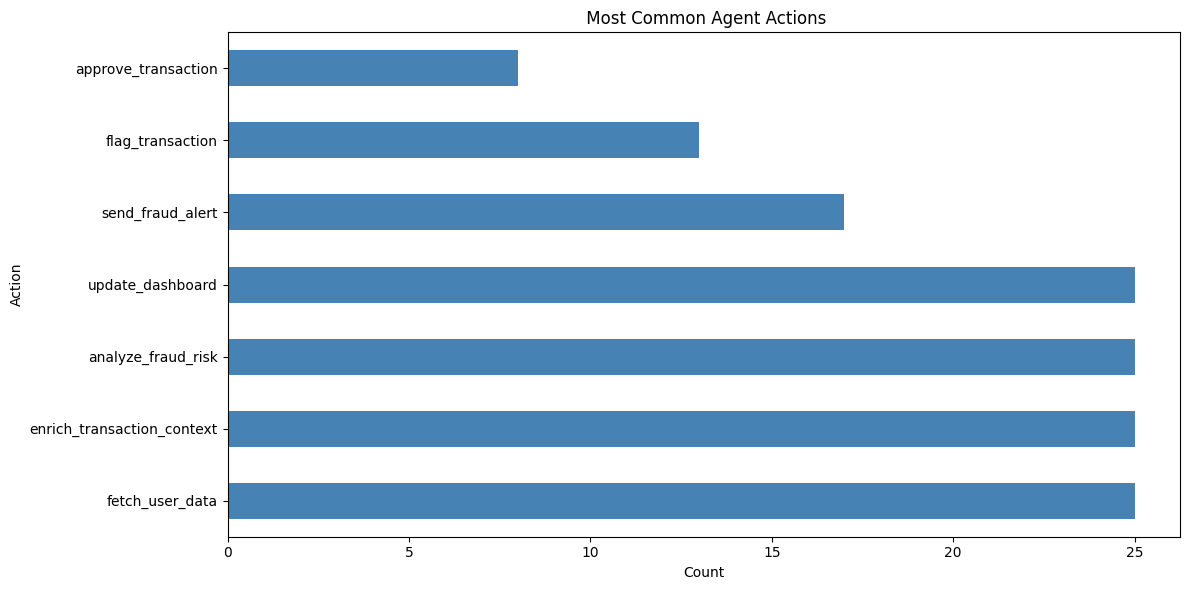


 AGENT DECISIONS ANALYSIS:
Total decision events: 113

Decisions by agent:
agent_decision          approve  approve_transaction  block  flag  \
agent_name                                                          
Alert Management Agent        0                    0      0     0   
FraudDetectionSystem          7                    0      2    16   
Risk Analysis Agent          16                    8      8    26   

agent_decision          flag_for_review  select_alert_channels  
agent_name                                                      
Alert Management Agent                0                     17  
FraudDetectionSystem                  0                      0  
Risk Analysis Agent                  13                      0  

 Decisions with Reasoning:
  • Decisions with reasoning: 63/113

 Sample Decisions:
  • FraudDetectionSystem decided: flag
    Reasoning: No reasoning
  • FraudDetectionSystem decided: flag
    Reasoning: No reasoning
  • FraudDetectionSystem decided: 

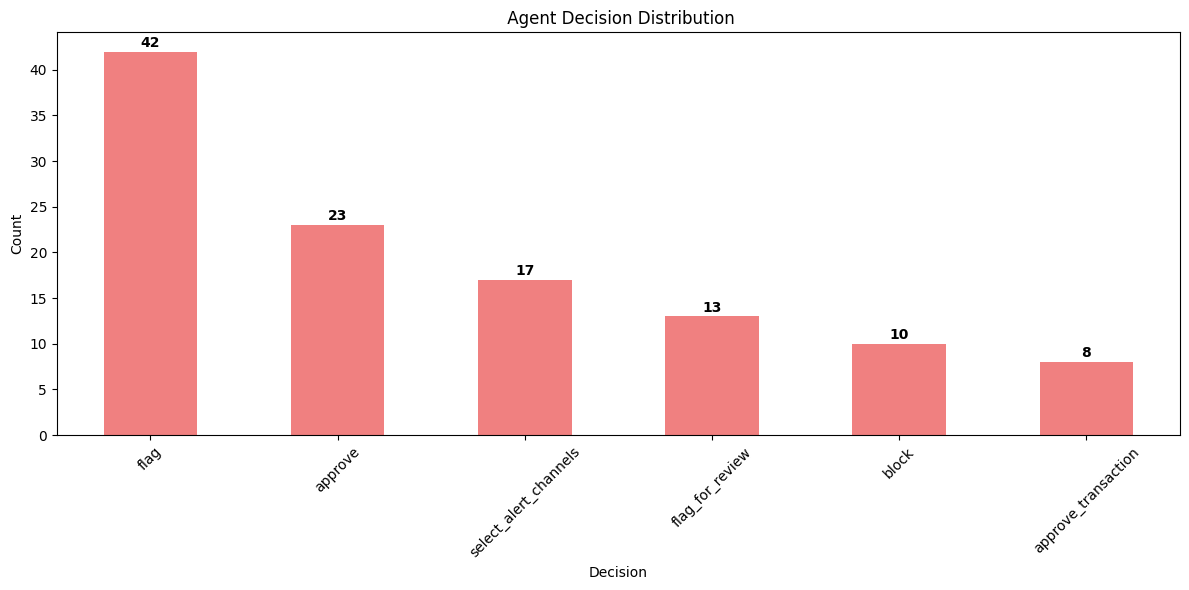


 AGENT OBSERVATIONS ANALYSIS:
Total observation events: 69

Observations by agent:
agent_name
Alert Management Agent    44
Data Collection Agent     25
dtype: int64

 Observation Sources:
observation_source
user_db      25
email        17
sms          10
slack        10
dashboard     7
Name: count, dtype: int64

 Average Observation Confidence: 0.929


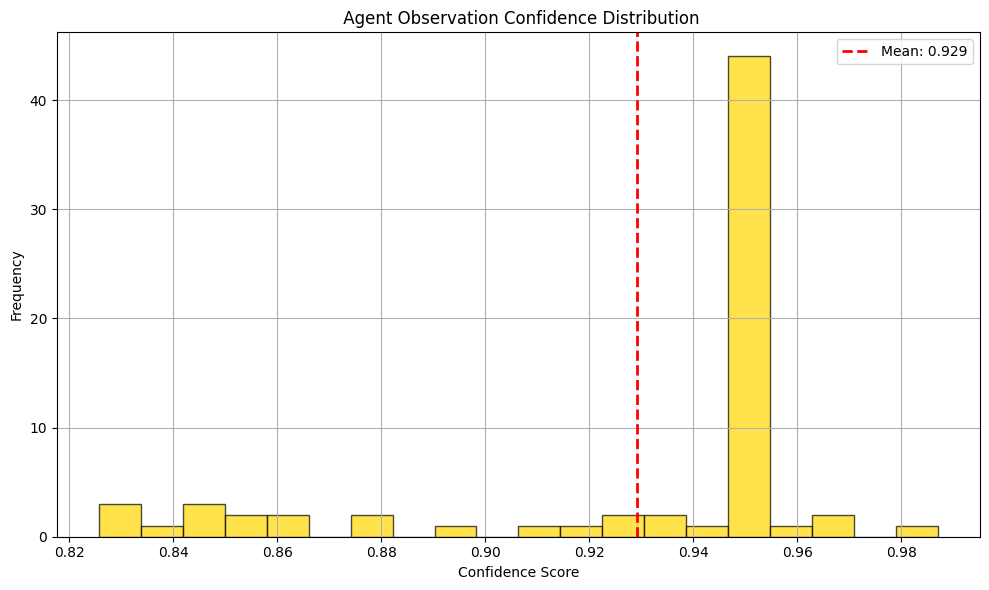


 Sample Observations:
  • Data Collection Agent observed: User profile retrieved successfully for user user_3602 (source: user_db)
  • Alert Management Agent observed: Alert successfully sent via email (source: email)
  • Alert Management Agent observed: Alert successfully sent via sms (source: sms)
  • Alert Management Agent observed: Alert successfully sent via slack (source: slack)
  • Data Collection Agent observed: User profile retrieved successfully for user user_4550 (source: user_db)

 AGENT WORKFLOW PATTERNS:
Analyzed 75 agent workflows

 Common Agent Workflow Patterns:
  • thinking → action → observation → thinking → action: 25 times
  • thinking → action → decision → decision → action: 21 times
  • thinking → decision → action → observation → observation → observation → action: 10 times
  • action: 8 times
  • thinking → decision → action → observation → observation → action: 7 times
  • thinking → action → decision: 4 times


In [7]:
# Agent Behavior Analysis using Abide AgentKit logging features
print(" AGENT BEHAVIOR ANALYSIS (Abide AgentKit)")
print("=" * 60)

if len(df) > 0:
    # 1. Agent Event Types Distribution
    print("\n Agent Event Types (from get_agent_logger):")
    agent_events = df[df['agent_event_type'].notna()]
    if len(agent_events) > 0:
        event_type_counts = agent_events['agent_event_type'].value_counts()
        print(event_type_counts)
        
        # Visualize agent event types
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # Pie chart
        axes[0].pie(event_type_counts.values, labels=event_type_counts.index, autopct='%1.1f%%', startangle=90)
        axes[0].set_title(' Agent Event Types Distribution')
        
        # Bar chart
        axes[1].bar(event_type_counts.index, event_type_counts.values, 
                   color=['#2E8B57', '#4169E1', '#FF6347', '#FFD700'][:len(event_type_counts)])
        axes[1].set_title(' Agent Event Types Count')
        axes[1].set_ylabel('Count')
        axes[1].tick_params(axis='x', rotation=45)
        
        for i, v in enumerate(event_type_counts.values):
            axes[1].text(i, v + 0.5, str(v), ha='center', fontweight='bold')
        
        plt.tight_layout()
        plt.show()
    else:
        print(" No agent event types found (thinking, action, decision, observation)")
    
    # 2. Agent Thinking Analysis
    print("\n AGENT THINKING ANALYSIS:")
    thinking_events = df[df['agent_thought'].notna()]
    if len(thinking_events) > 0:
        print(f"Total thinking events: {len(thinking_events)}")
        
        # Thinking by agent
        thinking_by_agent = thinking_events.groupby('agent_name').size()
        print("\nThinking events by agent:")
        print(thinking_by_agent)
        
        # Sample thoughts
        print("\n Sample Agent Thoughts:")
        for idx, row in thinking_events[['agent_name', 'agent_thought', 'timestamp']].head(5).iterrows():
            thought_preview = str(row['agent_thought'])[:100] + "..." if len(str(row['agent_thought'])) > 100 else str(row['agent_thought'])
            print(f"  • {row['agent_name']}: {thought_preview}")
    else:
        print("No thinking events found")
    
    # 3. Agent Actions Analysis
    print("\n AGENT ACTIONS ANALYSIS:")
    action_events = df[df['agent_action'].notna()]
    if len(action_events) > 0:
        print(f"Total action events: {len(action_events)}")
        
        # Actions by agent
        actions_by_agent = action_events.groupby(['agent_name', 'agent_action']).size().unstack(fill_value=0)
        print("\nActions by agent:")
        print(actions_by_agent)
        
        # Most common actions
        print("\n Most Common Actions:")
        top_actions = action_events['agent_action'].value_counts().head(10)
        for action, count in top_actions.items():
            print(f"  • {action}: {count} times")
        
        # Visualize actions
        if len(top_actions) > 0:
            plt.figure(figsize=(12, 6))
            top_actions.plot(kind='barh', color='steelblue')
            plt.title(' Most Common Agent Actions')
            plt.xlabel('Count')
            plt.ylabel('Action')
            plt.tight_layout()
            plt.show()
    else:
        print("No action events found")
    
    # 4. Agent Decisions Analysis
    print("\n AGENT DECISIONS ANALYSIS:")
    decision_events = df[df['agent_decision'].notna()]
    if len(decision_events) > 0:
        print(f"Total decision events: {len(decision_events)}")
        
        # Decisions by agent
        decisions_by_agent = decision_events.groupby(['agent_name', 'agent_decision']).size().unstack(fill_value=0)
        print("\nDecisions by agent:")
        print(decisions_by_agent)
        
        # Decisions with reasoning
        print("\n Decisions with Reasoning:")
        decisions_with_reasoning = decision_events[decision_events['agent_reasoning'].notna()]
        print(f"  • Decisions with reasoning: {len(decisions_with_reasoning)}/{len(decision_events)}")
        
        # Sample decisions
        print("\n Sample Decisions:")
        for idx, row in decision_events[['agent_name', 'agent_decision', 'agent_reasoning']].head(5).iterrows():
            reasoning_preview = str(row['agent_reasoning'])[:80] + "..." if pd.notna(row['agent_reasoning']) and len(str(row['agent_reasoning'])) > 80 else str(row['agent_reasoning']) if pd.notna(row['agent_reasoning']) else "No reasoning"
            print(f"  • {row['agent_name']} decided: {row['agent_decision']}")
            print(f"    Reasoning: {reasoning_preview}")
        
        # Decision distribution
        if len(decision_events) > 0:
            plt.figure(figsize=(12, 6))
            decision_counts = decision_events['agent_decision'].value_counts()
            decision_counts.plot(kind='bar', color='lightcoral')
            plt.title(' Agent Decision Distribution')
            plt.xlabel('Decision')
            plt.ylabel('Count')
            plt.xticks(rotation=45)
            for i, v in enumerate(decision_counts.values):
                plt.text(i, v + 0.5, str(v), ha='center', fontweight='bold')
            plt.tight_layout()
            plt.show()
    else:
        print("No decision events found")
    
    # 5. Agent Observations Analysis
    print("\n AGENT OBSERVATIONS ANALYSIS:")
    observation_events = df[df['agent_observation'].notna()]
    if len(observation_events) > 0:
        print(f"Total observation events: {len(observation_events)}")
        
        # Observations by agent
        obs_by_agent = observation_events.groupby('agent_name').size()
        print("\nObservations by agent:")
        print(obs_by_agent)
        
        # Observation sources
        obs_sources = observation_events['observation_source'].value_counts()
        if len(obs_sources) > 0:
            print("\n Observation Sources:")
            print(obs_sources)
        
        # Observation confidence
        obs_with_confidence = observation_events[observation_events['observation_confidence'].notna()]
        if len(obs_with_confidence) > 0:
            avg_confidence = obs_with_confidence['observation_confidence'].mean()
            print(f"\n Average Observation Confidence: {avg_confidence:.3f}")
            
            # Confidence distribution
            plt.figure(figsize=(10, 6))
            obs_with_confidence['observation_confidence'].hist(bins=20, alpha=0.7, color='gold', edgecolor='black')
            plt.axvline(avg_confidence, color='red', linestyle='--', linewidth=2, 
                       label=f'Mean: {avg_confidence:.3f}')
            plt.title(' Agent Observation Confidence Distribution')
            plt.xlabel('Confidence Score')
            plt.ylabel('Frequency')
            plt.legend()
            plt.tight_layout()
            plt.show()
        
        # Sample observations
        print("\n Sample Observations:")
        for idx, row in observation_events[['agent_name', 'agent_observation', 'observation_source']].head(5).iterrows():
            obs_preview = str(row['agent_observation'])[:80] + "..." if len(str(row['agent_observation'])) > 80 else str(row['agent_observation'])
            source = row['observation_source'] if pd.notna(row['observation_source']) else "unknown"
            print(f"  • {row['agent_name']} observed: {obs_preview} (source: {source})")
    else:
        print("No observation events found")
    
    # 6. Agent Workflow Patterns
    print("\n AGENT WORKFLOW PATTERNS:")
    print("=" * 40)
    
    # Analyze sequences of agent events within runs
    runs_with_agent_events = df[df['run_id'].notna() & df['agent_event_type'].notna()].copy()
    if len(runs_with_agent_events) > 0:
        # Group by run_id and agent_name to see event sequences
        workflow_patterns = runs_with_agent_events.groupby(['run_id', 'agent_name'])['agent_event_type'].apply(list)
        
        print(f"Analyzed {len(workflow_patterns)} agent workflows")
        
        # Find common patterns
        pattern_counts = {}
        for pattern in workflow_patterns.values:
            pattern_str = " → ".join(pattern)
            pattern_counts[pattern_str] = pattern_counts.get(pattern_str, 0) + 1
        
        if len(pattern_counts) > 0:
            print("\n Common Agent Workflow Patterns:")
            sorted_patterns = sorted(pattern_counts.items(), key=lambda x: x[1], reverse=True)
            for pattern, count in sorted_patterns[:10]:
                print(f"  • {pattern}: {count} times")

else:
    print(" No data available for agent behavior analysis")

##  Agent Decision Reasoning Analysis

Deep dive into how agents make decisions and their reasoning patterns.


 AGENT DECISION REASONING ANALYSIS

 Decision Quality Analysis:

 FraudDetectionSystem:
  • Total Decisions: 25
  • With Reasoning: 0 (0.0%)
  • Decision Types: {'flag': np.int64(16), 'approve': np.int64(7), 'block': np.int64(2)}

 Risk Analysis Agent:
  • Total Decisions: 71
  • With Reasoning: 46 (64.8%)
  • Decision Types: {'flag': np.int64(26), 'approve': np.int64(16), 'flag_for_review': np.int64(13), 'block': np.int64(8), 'approve_transaction': np.int64(8)}

 Alert Management Agent:
  • Total Decisions: 17
  • With Reasoning: 17 (100.0%)
  • Decision Types: {'select_alert_channels': np.int64(17)}

 Reasoning Quality Metrics:
  • Average Reasoning Length: 61 characters
  • Median Reasoning Length: 50 characters
  • Min Reasoning Length: 46 characters
  • Max Reasoning Length: 113 characters


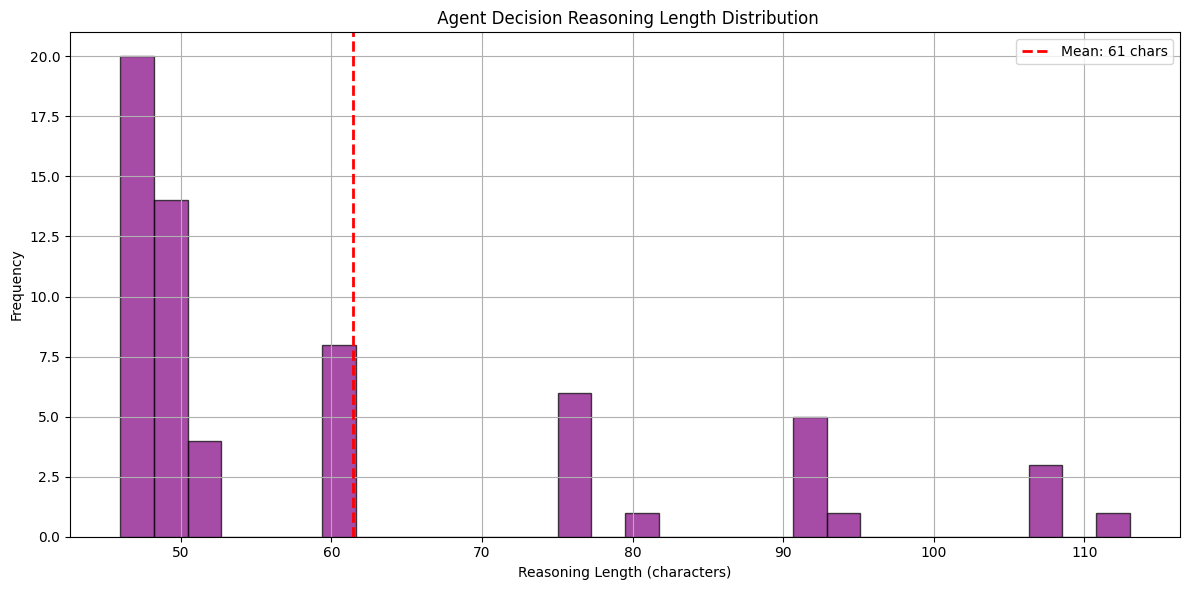


 Decisions with Options: 113
  • Average Options per Decision: 3.2
  • Max Options: 5

 Decision-Outcome Correlation:
                       success_rate  avg_latency_ms  count
agent_decision                                            
approve                       100.0             NaN     23
approve_transaction           100.0             NaN      8
block                         100.0             NaN     10
flag                          100.0             NaN     42
flag_for_review               100.0             NaN     13
select_alert_channels         100.0             NaN     17


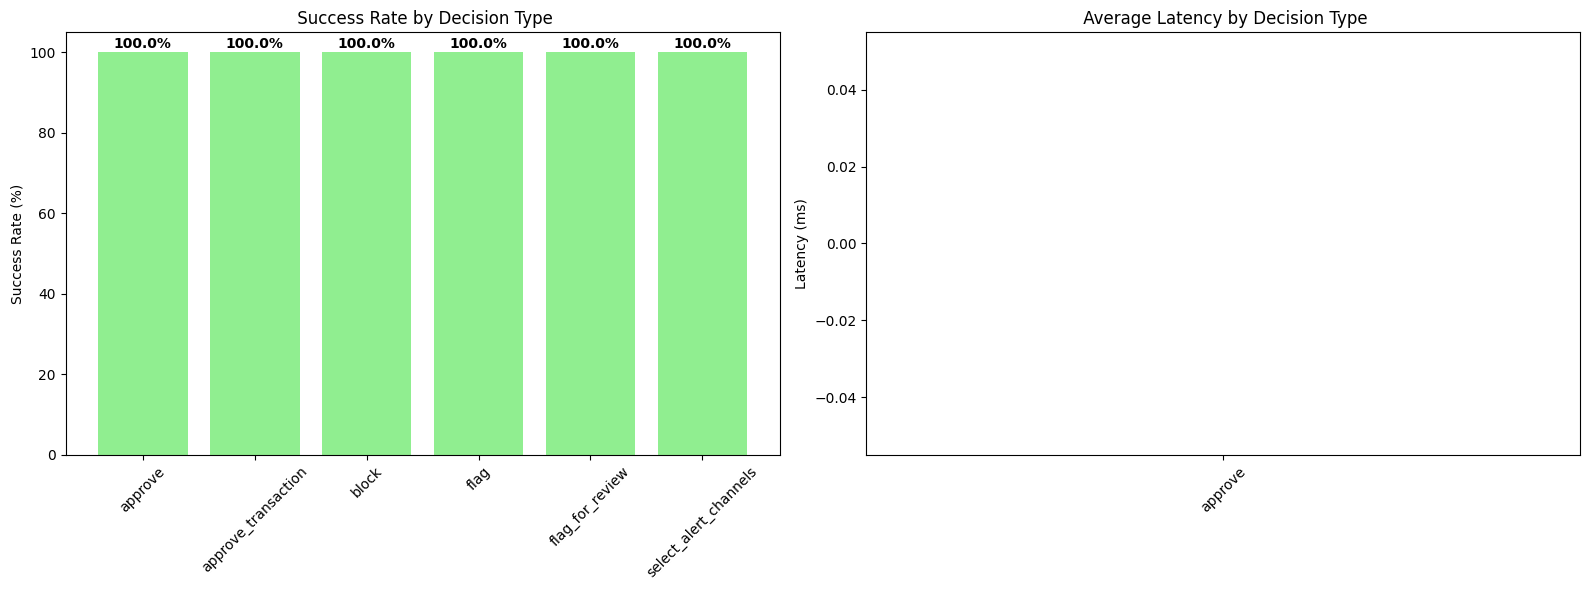

In [8]:
# Agent Decision Reasoning Deep Dive
print(" AGENT DECISION REASONING ANALYSIS")
print("=" * 50)

if len(df) > 0:
    decision_events = df[df['agent_decision'].notna()].copy()
    
    if len(decision_events) > 0:
        # Decisions by agent with reasoning quality
        print("\n Decision Quality Analysis:")
        for agent in decision_events['agent_name'].unique():
            if pd.notna(agent):
                agent_decisions = decision_events[decision_events['agent_name'] == agent]
                total = len(agent_decisions)
                with_reasoning = len(agent_decisions[agent_decisions['agent_reasoning'].notna()])
                reasoning_rate = (with_reasoning / total * 100) if total > 0 else 0
                
                print(f"\n {agent}:")
                print(f"  • Total Decisions: {total}")
                print(f"  • With Reasoning: {with_reasoning} ({reasoning_rate:.1f}%)")
                print(f"  • Decision Types: {dict(agent_decisions['agent_decision'].value_counts())}")
        
        # Decision reasoning length analysis
        decisions_with_reasoning = decision_events[decision_events['agent_reasoning'].notna()].copy()
        if len(decisions_with_reasoning) > 0:
            decisions_with_reasoning['reasoning_length'] = decisions_with_reasoning['agent_reasoning'].str.len()
            
            print(f"\n Reasoning Quality Metrics:")
            print(f"  • Average Reasoning Length: {decisions_with_reasoning['reasoning_length'].mean():.0f} characters")
            print(f"  • Median Reasoning Length: {decisions_with_reasoning['reasoning_length'].median():.0f} characters")
            print(f"  • Min Reasoning Length: {decisions_with_reasoning['reasoning_length'].min():.0f} characters")
            print(f"  • Max Reasoning Length: {decisions_with_reasoning['reasoning_length'].max():.0f} characters")
            
            # Visualize reasoning length distribution
            plt.figure(figsize=(12, 6))
            decisions_with_reasoning['reasoning_length'].hist(bins=30, alpha=0.7, color='purple', edgecolor='black')
            plt.axvline(decisions_with_reasoning['reasoning_length'].mean(), color='red', 
                       linestyle='--', linewidth=2, label=f'Mean: {decisions_with_reasoning["reasoning_length"].mean():.0f} chars')
            plt.title(' Agent Decision Reasoning Length Distribution')
            plt.xlabel('Reasoning Length (characters)')
            plt.ylabel('Frequency')
            plt.legend()
            plt.tight_layout()
            plt.show()
        
        # Decision options analysis
        decisions_with_options = decision_events[decision_events['agent_options'].notna()].copy()
        if len(decisions_with_options) > 0:
            print(f"\n Decisions with Options: {len(decisions_with_options)}")
            
            # Try to extract option counts
            option_counts = []
            for options_str in decisions_with_options['agent_options'].dropna():
                if options_str and options_str != '{}' and options_str != 'None':
                    try:
                        # Count keys in the options dict
                        options_dict = eval(options_str) if isinstance(options_str, str) else options_str
                        if isinstance(options_dict, dict):
                            option_counts.append(len(options_dict))
                    except:
                        pass
            
            if len(option_counts) > 0:
                print(f"  • Average Options per Decision: {np.mean(option_counts):.1f}")
                print(f"  • Max Options: {max(option_counts)}")
        
        # Decision correlation with outcomes
        print(f"\n Decision-Outcome Correlation:")
        decision_outcomes = decision_events.groupby('agent_decision').agg({
            'success': 'mean',
            'latency_ms': 'mean',
            'agent_decision': 'count'
        })
        decision_outcomes.columns = ['success_rate', 'avg_latency_ms', 'count']
        decision_outcomes['success_rate'] = decision_outcomes['success_rate'] * 100
        print(decision_outcomes.round(2))
        
        # Visualize decision outcomes
        if len(decision_outcomes) > 0:
            fig, axes = plt.subplots(1, 2, figsize=(16, 6))
            
            # Success rate by decision
            axes[0].bar(decision_outcomes.index, decision_outcomes['success_rate'], color='lightgreen')
            axes[0].set_title(' Success Rate by Decision Type')
            axes[0].set_ylabel('Success Rate (%)')
            axes[0].set_ylim(0, 105)
            axes[0].tick_params(axis='x', rotation=45)
            for i, v in enumerate(decision_outcomes['success_rate']):
                axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
            
            # Latency by decision
            axes[1].bar(decision_outcomes.index, decision_outcomes['avg_latency_ms'], color='lightcoral')
            axes[1].set_title(' Average Latency by Decision Type')
            axes[1].set_ylabel('Latency (ms)')
            axes[1].tick_params(axis='x', rotation=45)
            for i, v in enumerate(decision_outcomes['avg_latency_ms']):
                axes[1].text(i, v + 1, f'{v:.1f}ms', ha='center', fontweight='bold')
            
            plt.tight_layout()
            plt.show()
    
    else:
        print(" No decision events found for analysis")

else:
    print(" No data available")

##  Agent Action Performance Analysis

Analyze the performance and patterns of agent actions across the fraud detection pipeline.


In [11]:
# Agent Action Performance Analysis

##  Agent and Pipeline Discovery

Discover all agents and pipelines in your telemetry data.


In [9]:
# Discover all agents and pipelines
print(" AGENT AND PIPELINE DISCOVERY")
print("=" * 60)

if len(df) > 0:
    # 1. List all unique agents
    print("\n ALL AGENTS:")
    print("=" * 30)
    
    agents = df[df['agent_name'].notna()].groupby('agent_name').agg({
        'event_id': 'count',
        'agent_role': 'first',
        'agent_version': 'first',
        'run_id': 'nunique',
        'timestamp': ['min', 'max']
    }).round(2)
    
    agents.columns = ['total_events', 'role', 'version', 'unique_runs', 'first_seen', 'last_seen']
    agents = agents.sort_values('total_events', ascending=False)
    
    print(f"Found {len(agents)} unique agent(s):\n")
    for agent_name, row in agents.iterrows():
        print(f" {agent_name}")
        if pd.notna(row['role']):
            print(f"   Role: {row['role']}")
        if pd.notna(row['version']):
            print(f"   Version: {row['version']}")
        print(f"   Total Events: {int(row['total_events']):,}")
        print(f"   Unique Runs: {int(row['unique_runs'])}")
        if pd.notna(row['first_seen']):
            print(f"   First Seen: {row['first_seen']}")
        if pd.notna(row['last_seen']):
            print(f"   Last Seen: {row['last_seen']}")
        print()
    
    # 2. List all pipelines
    print("\n ALL PIPELINES:")
    print("=" * 30)
    
    # Extract pipeline identifiers from various sources
    pipeline_sources = []
    
    # From metadata
    pipeline_from_metadata = df[df['metadata_json'].notna()].copy()
    if len(pipeline_from_metadata) > 0:
        for idx, row in pipeline_from_metadata.iterrows():
            try:
                metadata = json.loads(row['metadata_json'])
                pipeline_id = metadata.get('pipeline_id') or metadata.get('pipeline') or metadata.get('system')
                if pipeline_id:
                    pipeline_sources.append({
                        'pipeline_id': pipeline_id,
                        'run_id': row['run_id'],
                        'agent_name': row['agent_name'],
                        'timestamp': row['timestamp']
                    })
            except:
                pass
    
    # From tags
    pipeline_from_tags = df[df['tags_json'].notna()].copy()
    if len(pipeline_from_tags) > 0:
        for idx, row in pipeline_from_tags.iterrows():
            try:
                tags = json.loads(row['tags_json'])
                pipeline_id = tags.get('pipeline') or tags.get('system')
                if pipeline_id:
                    pipeline_sources.append({
                        'pipeline_id': pipeline_id,
                        'run_id': row['run_id'],
                        'agent_name': row['agent_name'],
                        'timestamp': row['timestamp']
                    })
            except:
                pass
    
    if pipeline_sources:
        pipelines_df = pd.DataFrame(pipeline_sources)
        pipelines_summary = pipelines_df.groupby('pipeline_id').agg({
            'run_id': 'nunique',
            'agent_name': lambda x: ', '.join(sorted(set(x.dropna()))),
            'timestamp': ['min', 'max']
        })
        
        pipelines_summary.columns = ['unique_runs', 'agents', 'first_seen', 'last_seen']
        
        # Count events per pipeline
        for pipeline_id in pipelines_summary.index:
            pipeline_events = len(df[
                (df['metadata_json'].str.contains(pipeline_id, na=False)) |
                (df['tags_json'].str.contains(pipeline_id, na=False))
            ])
            pipelines_summary.loc[pipeline_id, 'total_events'] = pipeline_events
        
        pipelines_summary = pipelines_summary.sort_values('total_events', ascending=False)
        
        print(f"Found {len(pipelines_summary)} unique pipeline(s):\n")
        for pipeline_id, row in pipelines_summary.iterrows():
            print(f" {pipeline_id}")
            print(f"   Total Events: {int(row['total_events']):,}")
            print(f"   Unique Runs: {int(row['unique_runs'])}")
            print(f"   Agents: {row['agents']}")
            if pd.notna(row['first_seen']):
                print(f"   First Seen: {row['first_seen']}")
            if pd.notna(row['last_seen']):
                print(f"   Last Seen: {row['last_seen']}")
            print()
    else:
        print("No pipelines found in metadata or tags.")
        print("\n Tip: Pipelines are identified by 'pipeline_id', 'pipeline', or 'system' in metadata/tags")
    
    # 3. Agent-Pipeline relationships
    print("\n AGENT-PIPELINE RELATIONSHIPS:")
    print("=" * 40)
    
    if pipeline_sources:
        agent_pipeline = pd.DataFrame(pipeline_sources).groupby(['agent_name', 'pipeline_id']).size()
        agent_pipeline = agent_pipeline.reset_index(name='interactions')
        agent_pipeline = agent_pipeline.sort_values('interactions', ascending=False)
        
        print("\nAgents by Pipeline:")
        for pipeline_id in agent_pipeline['pipeline_id'].unique():
            pipeline_agents = agent_pipeline[agent_pipeline['pipeline_id'] == pipeline_id]
            print(f"\n   {pipeline_id}:")
            for _, row in pipeline_agents.iterrows():
                print(f"    • {row['agent_name']}: {row['interactions']} interactions")
    
    # 4. Quick query examples
    print("\n QUICK QUERY EXAMPLES:")
    print("=" * 30)
    print("# Get all events for a specific agent:")
    print("agent_events = df[df['agent_name'] == 'Risk Analysis Agent']")
    print()
    print("# Get all events for a specific pipeline:")
    print("pipeline_events = df[df['metadata_json'].str.contains('fraud_detection', na=False)]")
    print()
    print("# Get unique agent names:")
    print("unique_agents = df['agent_name'].dropna().unique()")
    print()
    print("# Get agent activity summary:")
    print("agent_summary = df.groupby('agent_name').agg({'event_id': 'count', 'run_id': 'nunique'})")

else:
    print(" No data available for discovery")


 AGENT AND PIPELINE DISCOVERY

 ALL AGENTS:
Found 4 unique agent(s):

 FraudDetectionSystem
   Total Events: 1,912
   Unique Runs: 150
   First Seen: 2025-11-06 18:13:49.983723
   Last Seen: 2025-11-11 01:23:57.928399

 Data Collection Agent
   Role: data-processor
   Total Events: 150
   Unique Runs: 25
   First Seen: 2025-11-11 01:23:42.056179
   Last Seen: 2025-11-11 01:23:57.561766

 Risk Analysis Agent
   Role: decision-maker
   Total Events: 142
   Unique Runs: 25
   First Seen: 2025-11-11 01:23:42.204971
   Last Seen: 2025-11-11 01:23:57.786934

 Alert Management Agent
   Role: notification
   Total Events: 120
   Unique Runs: 25
   First Seen: 2025-11-11 01:23:42.450202
   Last Seen: 2025-11-11 01:23:57.927706


 ALL PIPELINES:
Found 3 unique pipeline(s):

 fraud_detection
   Total Events: 2,474
   Unique Runs: 275
   Agents: FraudDetectionSystem
   First Seen: 2025-11-06 18:13:49.984397
   Last Seen: 2025-11-11 01:23:57.929606

 main
   Total Events: 2,149
   Unique Runs: 175
